In [1]:
!pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import random


#!unzip flickr8k.zip -d

In [2]:
image_dir = r"C:\Users\janas\Downloads\flickr8k\Images"
caption_file = r"C:\Users\janas\Downloads\flickr8k\captions.txt"


In [3]:
def validate_paths(image_dir, caption_file):
  if not os.path.exists(image_dir):
    raise ValueError(f"Image directory not found: {image_dir}")
  if not os.path.exists(caption_file):
    raise ValueError(f"Caption file not found: {caption_file}")

  print("Dataset paths validated")
  print("Images:", len(os.listdir(image_dir)))
  print("Caption file:", caption_file)

# Redefine image_dir and caption_file to correct Colab paths
image_dir = r"C:\Users\janas\Downloads\flickr8k\Images"
caption_file = r"C:\Users\janas\Downloads\flickr8k\captions.txt"

validate_paths(image_dir, caption_file)

Dataset paths validated
Images: 8091
Caption file: C:\Users\janas\Downloads\flickr8k\captions.txt


In [10]:
def load_captions(filename):
    captions = {}

    with open(filename, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f):
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            # Skip header if present
            if line_num == 0 and line.lower().startswith("image"):
                continue

            # ✅ Split ONLY on the first comma
            try:
                img, caption = line.split(",", 1)
            except ValueError:
                # Extremely malformed line
                print(f"Warning: Skipping malformed line {line_num + 1}")
                continue

            img_id = img.split("#")[0]

            # Basic text cleaning (safe)
            caption = caption.lower().strip()

            # Remove unwanted characters but KEEP sentence structure
            caption = re.sub(r"[\"\'`]", "", caption)

            # Normalize spaces
            caption = re.sub(r"\s+", " ", caption)

            caption = "<start> " + caption + " <end>"

            if img_id not in captions:
                captions[img_id] = []

            captions[img_id].append(caption)

    return captions

captions = load_captions(caption_file)


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<unk>",
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~\t\n'
)

all_captions = []
for caps in captions.values():
    all_captions.extend(caps)

tokenizer.fit_on_texts(all_captions)

# ---- MAX CAPTION LENGTH ----
MAX_LEN = max(
    len(tokenizer.texts_to_sequences([cap])[0])
    for caps_list in captions.values()
    for cap in caps_list
)

print("MAX_LEN:", MAX_LEN)


word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}

start_token = tokenizer.word_index["<start>"]
end_token = tokenizer.word_index["<end>"]


MAX_LEN: 39


In [12]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img


In [13]:
def data_generator_seq(image_ids, captions, batch_size=32):
    while True:
        batch_img, batch_in, batch_out = [], [], []

        for img_id in image_ids:
            img_path = os.path.join(image_dir, img_id)
            img = load_image(img_path)

            for cap in captions[img_id]:
                seq = tokenizer.texts_to_sequences([cap])[0]

                in_seq = seq[:-1]
                out_seq = seq[1:]

                in_seq = pad_sequences([in_seq], maxlen=MAX_LEN, padding="post")[0]
                out_seq = pad_sequences([out_seq], maxlen=MAX_LEN, padding="post")[0]

                batch_img.append(img)
                batch_in.append(in_seq)
                batch_out.append(out_seq)

                if len(batch_img) == batch_size:
                    yield (
                        (np.array(batch_img), np.array(batch_in)),
                        np.array(batch_out)
                    )
                    batch_img, batch_in, batch_out = [], [], []



In [14]:
train_images = os.listdir(image_dir)

dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(train_images, captions),
    output_signature=(
        (tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
         tf.TensorSpec(shape=(MAX_LEN,), dtype=tf.int32)),
        tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32)  # single token
    )
)
dataset = dataset.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

In [15]:
def dataset_stats(captions, image_paths, tokenizer):
    caption_lenghts = []
    for caps in captions.values():
        for cap in caps:
            caption_lenghts.append(len(cap.split()))
    #return caption_lenghts
    print("\nDataset Statistics:")
    print("-" * 30)
    print("Total Images:", len(image_paths))
    print("Total captions:", len(caption_lenghts))
    print("Vocabulary Size:", len(tokenizer.word_index)+1)
    print("Average Caption Length:", np.mean(caption_lenghts))
    print("Max Caption Length:", np.max(caption_lenghts))

dataset_stats(captions, train_images, tokenizer)


Dataset Statistics:
------------------------------
Total Images: 8091
Total captions: 40455
Vocabulary Size: 8493
Average Caption Length: 13.775973303670746
Max Caption Length: 40


In [16]:
import random

# Get all unique image IDs that have captions
all_image_ids = list(captions.keys())

# Shuffle for random split
random.shuffle(all_image_ids)

# 80–20 split
split_index = int(len(all_image_ids) * 0.8)
train_img_ids = all_image_ids[:split_index]
test_img_ids  = all_image_ids[split_index:]

print(f"Number of training images: {len(train_img_ids)}")
print(f"Number of testing images: {len(test_img_ids)}")

# ---- TRAIN DATASET ----
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_seq(train_img_ids, captions),
    output_signature=(
        (
            tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32),
        ),
        tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32),
    )
).prefetch(tf.data.AUTOTUNE)

# ---- TEST DATASET 
test_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_seq(test_img_ids, captions),
    output_signature=(
        (
            tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32),
        ),
        tf.TensorSpec(shape=(None, MAX_LEN), dtype=tf.int32),
    )
).prefetch(tf.data.AUTOTUNE)



Number of training images: 6472
Number of testing images: 1619


In [17]:
def ImageEncoder(embed_dim):
    base = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    base.trainable = False

    img_in = layers.Input(shape=(224,224,3))
    x = base(img_in)
    x = layers.Dense(embed_dim, activation="relu")(x)

    return models.Model(img_in, x)

In [18]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

#def TextEncoder(vocab_size, embed_dim):
#    inputs = layers.Input(shape=(None,))
#    x = layers.Embedding(vocab_size, embed_dim)(inputs)
#    x = TransformerEncoder(embed_dim, num_heads=4, ff_dim=256)(x)
    #x = x + positional_encoding(seq_len, embed_dim)
#    return models.Model(inputs, x, name="TextEncoder")

In [19]:
class MultimodalFusion(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(4, embed_dim)

    def call(self, img_feat, txt_feat):
        img_feat = tf.expand_dims(img_feat, 1)
        txt_feat = tf.expand_dims(txt_feat, 1)
        fused = self.att(txt_feat, img_feat, img_feat)
        return tf.squeeze(fused, 1)

In [20]:
class MultimodalTransformer(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=4, key_dim=embed_dim)
        self.norm = layers.LayerNormalization()

    def call(self, img_feat, txt_feat):
        img_feat = tf.expand_dims(img_feat, 1)
        attn = self.att(txt_feat, img_feat, img_feat)
        return self.norm(attn + txt_feat)


In [21]:
def ImageCaptioningModel(vocab_size, embed_dim=256):

    img_input = layers.Input(shape=(224,224,3))
    txt_input = layers.Input(shape=(MAX_LEN,))

    # Image encoder
    img_feat = ImageEncoder(embed_dim)(img_input)

    # Text embedding
    txt_embed = layers.Embedding(vocab_size, embed_dim)(txt_input)

    # 🔥 Inject image features into every timestep
    img_proj = layers.Dense(embed_dim)(img_feat)
    img_proj = layers.Reshape((1, embed_dim))(img_proj)
    txt_embed = txt_embed + img_proj

    # LSTM decoder (image-conditioned)
    lstm_out = layers.LSTM(
        embed_dim,
        return_sequences=True
    )(txt_embed, initial_state=[img_feat, img_feat])

    # Word prediction
    outputs = layers.TimeDistributed(
        layers.Dense(vocab_size, activation="softmax")
    )(lstm_out)

    return models.Model([img_input, txt_input], outputs)


In [22]:
vocab_size = len(tokenizer.word_index) + 1

model = ImageCaptioningModel(vocab_size)

def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true, y_pred
    )
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=masked_loss,
    metrics=["accuracy"]
)


history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=7,
    steps_per_epoch=300,
    validation_steps=100
)




Epoch 1/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 294s 957ms/step - accuracy: 0.0396 - loss: 6.1280 - val_accuracy: 0.0518 - val_loss: 5.3160
Epoch 2/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 284s 948ms/step - accuracy: 0.0508 - loss: 5.2688 - val_accuracy: 0.0511 - val_loss: 5.2036
Epoch 3/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 285s 952ms/step - accuracy: 0.0517 - loss: 5.1559 - val_accuracy: 0.0518 - val_loss: 5.1048
Epoch 4/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 284s 948ms/step - accuracy: 0.0514 - loss: 5.0895 - val_accuracy: 0.0521 - val_loss: 5.0125
Epoch 5/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 283s 943ms/step - accuracy: 0.0560 - loss: 4.9633 - val_accuracy: 0.0607 - val_loss: 4.9034
Epoch 6/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 283s 945ms/step - accuracy: 0.0624 - loss: 4.8425 - val_accuracy: 0.0649 - val_loss: 4.7962
Epoch 7/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 283s 944ms/step - accuracy: 0.0671 - loss: 4.7773 - val_accuracy: 0.0693 - val_loss: 4.7056


In [24]:
def generate_caption_lstm(model, image_path, temperature=0.6):
    img = load_image(image_path)
    img = tf.expand_dims(img, 0)

    caption = [start_token]

    for _ in range(MAX_LEN):
        seq = pad_sequences(
            [caption],
            maxlen=MAX_LEN,
            padding="post"
        )

        preds = model.predict([img, seq], verbose=0)

        probs = preds[0, len(caption)-1]

        # ✅ TEMPERATURE SCALING (ADD HERE)
        probs = np.log(probs + 1e-9) / temperature
        probs = np.exp(probs)
        probs = probs / np.sum(probs)

        next_word = np.random.choice(len(probs), p=probs)

        if next_word == end_token:
            break

        caption.append(next_word)

    return " ".join(
    index_word.get(i, "")
    for i in caption[1:]
    if index_word.get(i, "") != "<unk>")




In [25]:
def show_image_with_caption(image_ids, n=6):
    plt.figure(figsize=(14, 4 * n))

    for i in range(n):
        img_id = image_ids[i]
        img_path = os.path.join(image_dir, img_id)

        caption = generate_caption_lstm(model, img_path)

        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)

        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(n, 2, 2*i + 2)
        plt.axis("off")
        plt.text(0.01, 0.5, caption, fontsize=14, wrap=True)

    plt.show()


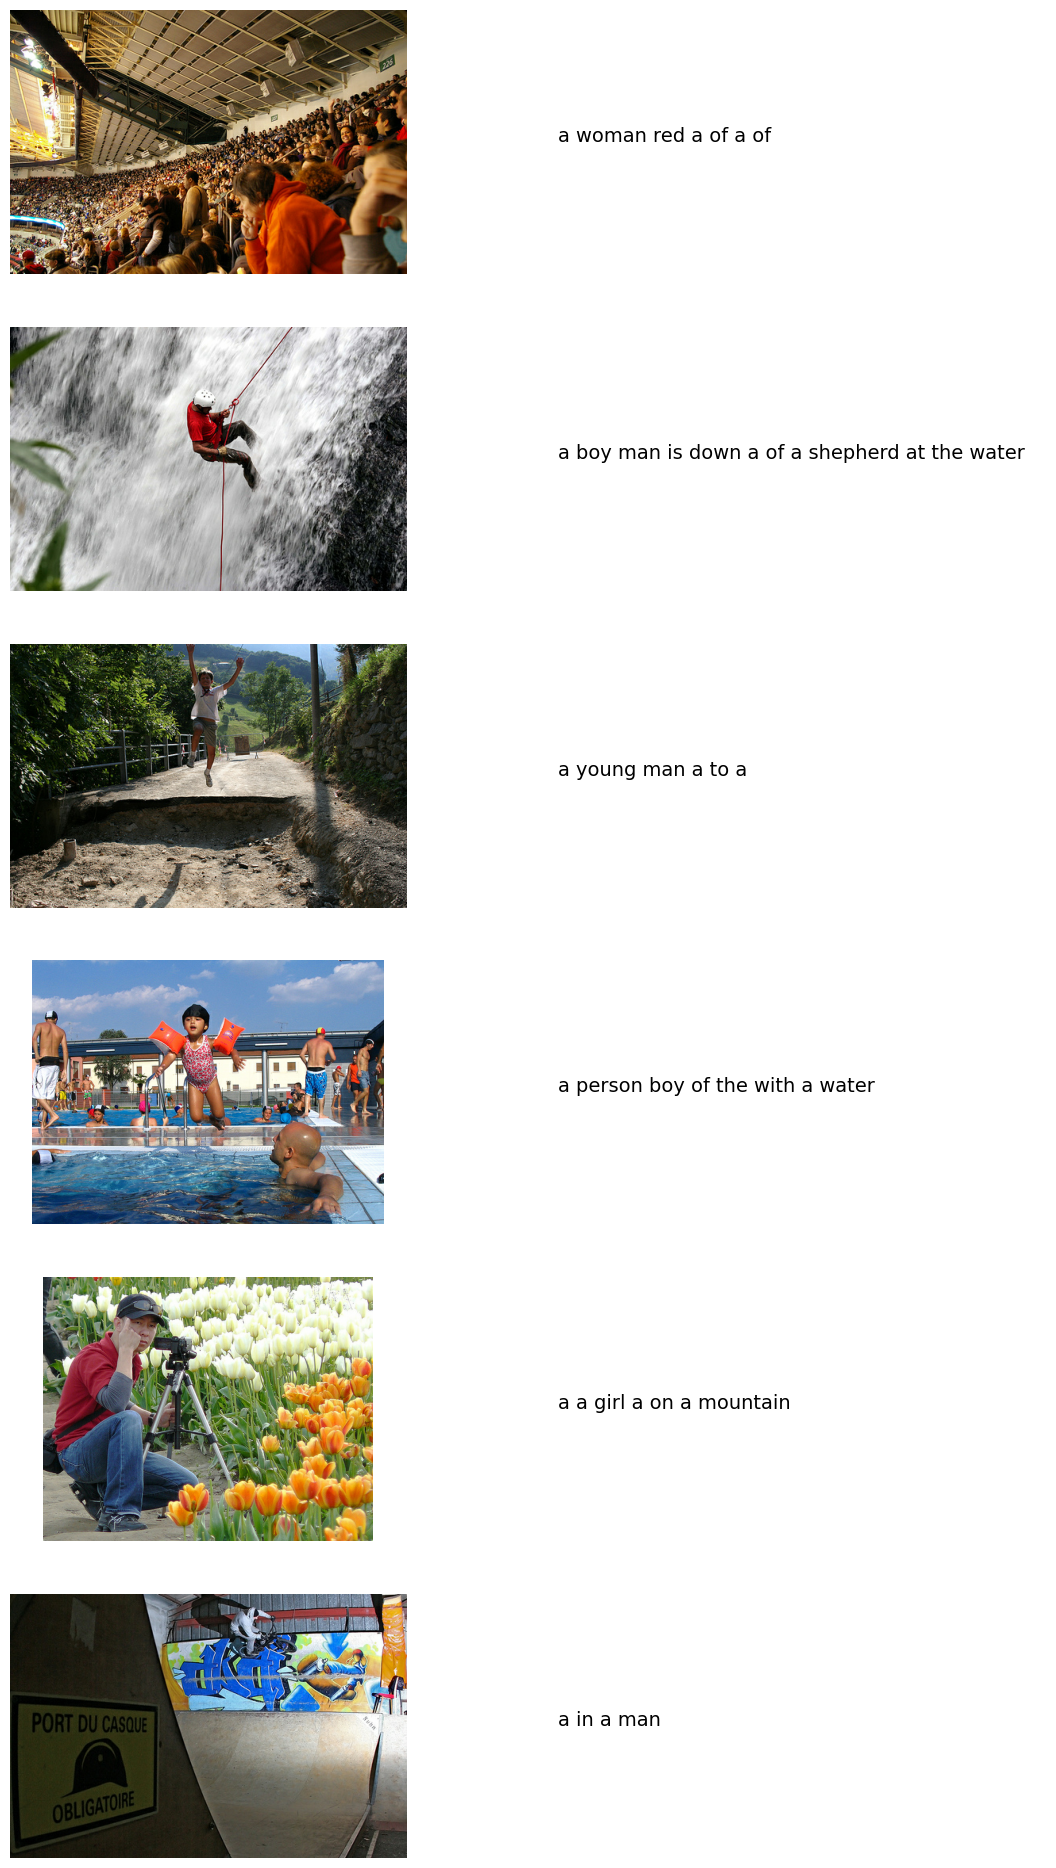

In [26]:
show_image_with_caption(test_img_ids, n=6)


In [20]:
print(test_img_ids[0])


3677302645_8cd3fac70d.jpg
